<font size =8> Barnacle Detection by Fine-Tuning a Model

<font size=6><u>Introduction</u>

<font size =4>In this approach, I make my own dataset from the two provided images and their respective masks, convert it into YOLO format and train a YOLOv8s model on the dataset. For training, I carry out a 5-fold cross validation test and report the results for each validation in the notebook below. Using the weights of the fold with the best performance, I carry out inference on the unseen images. 


In [2]:
from ultralytics import YOLO 
import matplotlib.pyplot as plt
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import fiftyone as fo 
from fiftyone.core.labels import Detections
import fiftyone.core.plots as fop
import fiftyone.brain as fob
import numpy as np
from PIL import Image
import ipywidgets

<font size= 5.5> <u>Image pre-processing</u>

<font size = 4> First, I carefully crop the images and their respective masks  to just include the portion within the central frame. Both the resulting images and their crops have the same dimensions and overlap over each other perfectly. After that, I define a function in my helper.py and use that function to further crop the images and their masks to overlapping images. I do this to create a larger sample of dataset and expose the model to a all types of images, ones with high clustering of barnacles and ones with low clustering.

In [ ]:
# #Creating patches for image1 and mask 1
# img1 = Image.open("images/image1.png").convert("RGB")
# mask1 = Image.open("masks/mask1.png").convert("L")  # Usually grayscale for masks
# assert img1.size == mask1.size
# coords_1 = compute_patch_coordinates(img1.size, patch_size=(256, 256), overlap_percentage=0.3)
# extract_patches_from_coords(img1, coords_1, output_dir="image_patches", prefix="image1")
# extract_patches_from_coords(mask1, coords_1, output_dir="mask_patches", prefix="mask1")


# #Creating patches for image2 and mask 2
# img2 = Image.open("images/image2.png").convert("RGB")
# mask2 = Image.open("masks/mask2.png").convert("L") 
# assert img2.size == mask2.size
# coords_2 = compute_patch_coordinates(img1.size, patch_size=(256, 256), overlap_percentage=0.3)
# extract_patches_from_coords(img2, coords_2, output_dir="image_patches", prefix="image2")
# extract_patches_from_coords(mask2, coords_2, output_dir="mask_patches", prefix="mask2")

<font size = 5.5> <u>Creating Fiftyone Dataset to measure performance</u>

<font size =4> For creating and handling my dataset, I utilize fiftyonean, an open-source Python library and app designed to help build datasets. 

In [ ]:
DATASET_NAME = "barnacle_dataset"
if fo.dataset_exists(DATASET_NAME):
    print(f"Deleting existing dataset: '{DATASET_NAME}'")
    fo.delete_dataset(DATASET_NAME)
    print(f"Dataset '{DATASET_NAME}' deleted successfully.")
else:
    print(f"Dataset '{DATASET_NAME}' does not exist (or was already deleted).")



patched_dataset = fo.Dataset.from_images_dir(
    "image_patches",
    name="barnacle_dataset",
    persistent=False
)

Deleting existing dataset: 'barnacle_v8'
Dataset 'barnacle_v8' deleted successfully.


<font size = 5>Adding Ground Truths and Predictions in the dataset 



<font size = 4> After creating a dataset using the image_patches directory, I add a label field called "ground_truth" to the dataset using the masks. The label field basically contains data for all the detections in the masked images, including bounding box coordinates, segment annotations, the classes of detected objects (just barnacle in this case) and th number of objects detected in every image. 

I computer these detections using connected components analysis, which basically helps me make contours on binary images, and calculate the co-ordinate of every contour. 

In [ ]:
import os 
MASK_DIR = "mask_patches"
IMAGE_DIR = "image_patches"
GROUND_TRUTH_FIELD = "ground_truth"
import cv2 

# I added this to if-else situation to avoid rerunning the entire script while debugging. 
if GROUND_TRUTH_FIELD not in patched_dataset.get_field_schema():
    print(f"Adding ground truth masks to the '{GROUND_TRUTH_FIELD}' field")
    
    filename_mapping = {
    os.path.basename(img): os.path.basename(mask)
    for img, mask in zip(sorted(os.listdir(IMAGE_DIR)), sorted(os.listdir(MASK_DIR)))
    if mask.endswith((".png", ".jpg", ".jpeg"))
}


    for sample in patched_dataset:   #Prepare masks for each image in the dataset
        img_filename = os.path.basename(sample.filepath)
        mask_filename = filename_mapping.get(img_filename) # handles cases where an image might not have a mask
        mask_path = os.path.join(MASK_DIR, mask_filename)

        if not os.path.exists(mask_path):
            print(f"Warning: Mask not found at {mask_path} for {img_filename}. Skipping ground truth for this sample.")
            continue

        # Use cv2.IMREAD_GRAYSCALE to ensure it's loaded as a single channel
        gt_mask_image = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        
        if gt_mask_image is None:
            print(f"Error: Could not load mask image from {mask_path}. Skipping ground truth.")
            continue

        # Binarizing
        _, binary_mask = cv2.threshold(gt_mask_image, 1, 255, cv2.THRESH_BINARY)

        # Connected component analysis
        num_labels, labels_img, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, 8, cv2.CV_32S)

        gt_detections = []

        for i in range(1, num_labels):
            # Create a boolean mask for the current instance
            instance_mask = (labels_img == i) 

            y_coords, x_coords = np.where(instance_mask)
            
            # Skip mask if empty 
            if y_coords.size == 0:
                continue

            x_min, x_max = x_coords.min(), x_coords.max()
            y_min, y_max = y_coords.min(), y_coords.max()

            img_height, img_width = gt_mask_image.shape[:2]
            
            bbox_width = max(1, x_max - x_min + 1)
            bbox_height = max(1, y_max - y_min + 1)

            rel_bounding_box = [
                x_min / img_width,
                y_min / img_height,
                bbox_width / img_width,
                bbox_height / img_height
            ]

            cropped_mask = instance_mask[y_min:y_max+1, x_min:x_max+1]

            gt_detections.append(
                fo.Detection(
                    label="barnacle",
                    bounding_box=rel_bounding_box,
                    mask=cropped_mask.astype(bool)  
                )
            )
        sample[GROUND_TRUTH_FIELD] = fo.Detections(detections=gt_detections)
        sample.save()

    print(f"Ground truth masks added to the '{GROUND_TRUTH_FIELD}' field for all samples.")
else:
    print(f"Field '{GROUND_TRUTH_FIELD}' already exists. Skipping ground truth addition.")

print(patched_dataset)
#Sanity Check 
sample = patched_dataset.first()
has_gt = sample.ground_truth is not None and len(sample.ground_truth.detections) > 0
print(f"Sample 1 has ground truth: {has_gt}")
print("-----------------------------------------------------------------------------------")

Adding ground truth masks to the 'ground_truth' field...
Ground truth masks added to the 'ground_truth' field for all samples.
Name:        barnacle_v8
Media type:  image
Num samples: 2
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
Sample 1 has ground truth: True
-------------------------------------------------------------------------------------------------------------------------------------


<font size = 5.5> Converting the dataset into favorable type for training

<font size =4> Once I have a dataset prepared in the fiftyone format, the next step was to convert it into YOLO format for training. I choose YOLO specifically here because the YOLOv8 model is very nice with instance segmentation and would work well with irregular objects like barnacles as compared to just bounding box detections. 


While the documentation on fiftyone says that I can directly convert the dataset to YOLO format (one of the major reasons I used it for this method) I kept getting bugs and errors while trying to do so. So, I tried anotther approach of converting it first to COCO and then from COCO to YOLO, which fortunaely worked!

<font size= 5>1. Converting into COCO dataset format (using fiftyone)

In [ ]:
import fiftyone.utils.yolo as fou
import fiftyone.types as fot

patched_dataset.export(
    export_dir="COCO_dataset",
    dataset_type=fot.COCODetectionDataset,
    label_field="ground_truth",
    export_media=True,    
)


Running model inference and adding predictions to the 'predictions' field...
Performing prediction on 49 slices.
Performing prediction on 49 slices.
Model predictions added to the 'predictions' field for all samples.
Name:        barnacle_v8
Media type:  image
Num samples: 2
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    predictions:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
Sample 1 has predictions field: True
-------------------------

<font size = 5>2. Converting fromm COCO to YOLO (using ultralytics)

In [ ]:
from ultralytics.data.converter import convert_coco

convert_coco("COCO_dataset/",save_dir= "yolo_dataset",  use_segments=True, use_keypoints=False, cls91to80=False)



<font size =6>Cross-Validation Training results.

<font size =4.5> Upon coverting the dataset into the desired YOLO format. I ran a 5-fold cross validation test on the model on a google colab(in the Training Results directory). Below are the training results for each fold. If you want to know more about each training, the KFold_training_barnacles contains all the information for each fold training. 

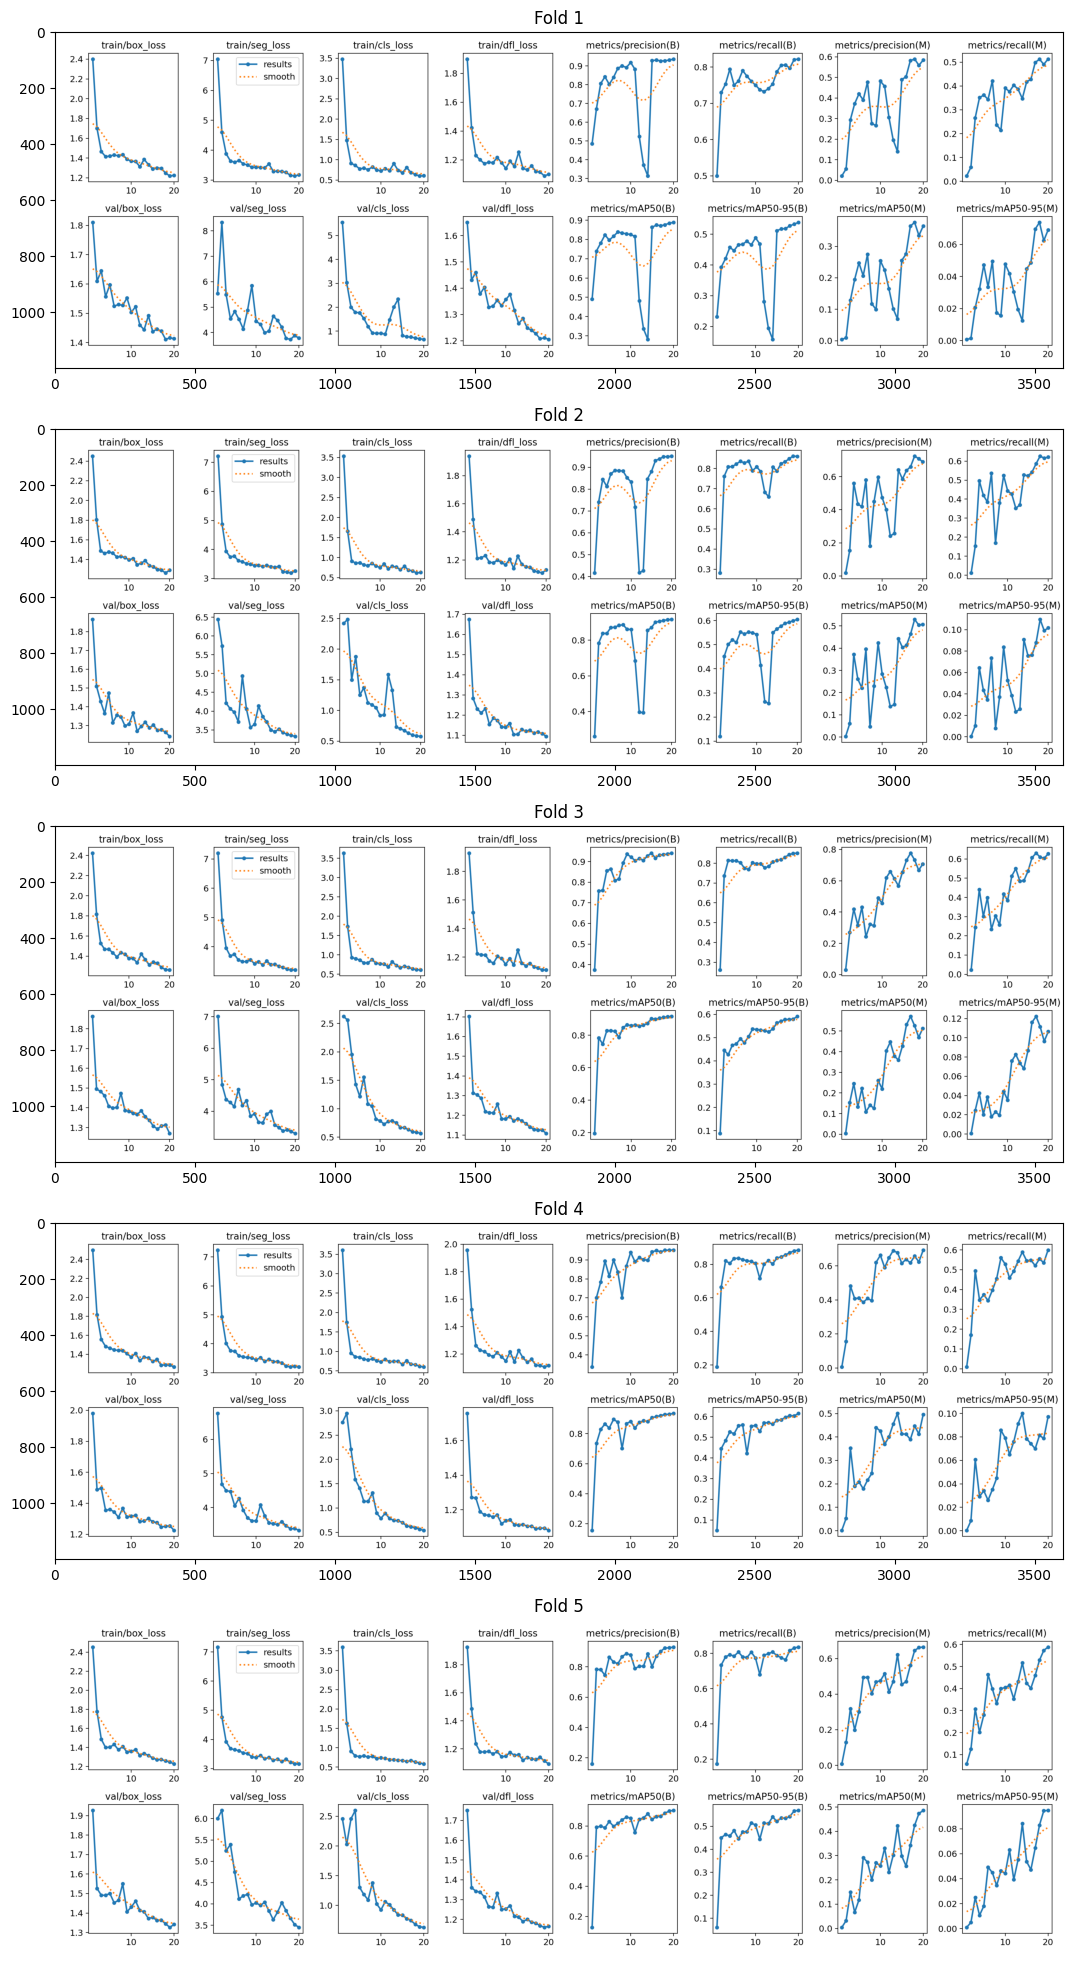

In [10]:
img1 = np.asarray(Image.open("KFold_training_barnacles/fold_1/results.png"))
img2 = np.asarray(Image.open("KFold_training_barnacles/fold_2/results.png"))
img3 = np.asarray(Image.open("KFold_training_barnacles/fold_3/results.png"))
img4 = np.asarray(Image.open("KFold_training_barnacles/fold_4/results.png"))
img5 = np.asarray(Image.open("KFold_training_barnacles/fold_5/results.png"))

fig, axes = plt.subplots(5,1, figsize=(20,20))

#fold1
axes[0].imshow(img1) 
axes[0].set_title('Fold 1')

#fold2
axes[1].imshow(img2) 
axes[1 ].set_title('Fold 2')

#fold3
axes[2].imshow(img3) 
axes[2].set_title('Fold 3')

#fold4
axes[3].imshow(img4)
axes[3].set_title('Fold 4')

#fold5
axes[4].imshow(img5) 
axes[4].set_title('Fold 5')


plt.tight_layout()
plt.axis('off')
plt.show()

In [35]:
plot.freeze()
print("---------------------------------------------------------------------------------------------------------------------------------------------------------------------")

07/26/2025 17:22:34 - INFO - choreographer.browsers.chromium -   Chromium init'ed with kwargs {}
07/26/2025 17:22:34 - INFO - choreographer.browsers.chromium -   Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe
07/26/2025 17:22:34 - INFO - choreographer.utils._tmpfile -   Temp directory created: C:\Users\arses\AppData\Local\Temp\tmpkgw9ubwu.
07/26/2025 17:22:34 - INFO - choreographer.browser_async -   Opening browser.
07/26/2025 17:22:34 - INFO - choreographer.utils._tmpfile -   Temp directory created: C:\Users\arses\AppData\Local\Temp\tmpkhlyf87b.
07/26/2025 17:22:34 - INFO - choreographer.browsers.chromium -   Temporary directory at: C:\Users\arses\AppData\Local\Temp\tmpkhlyf87b
07/26/2025 17:22:35 - INFO - kaleido.kaleido -   Conforming 1 to file:///C:/Users/arses/AppData/Local/Temp/tmpkgw9ubwu/index.html
07/26/2025 17:22:35 - INFO - kaleido.kaleido -   Waiting on all navigates
07/26/2025 17:22:37 - INFO - kaleido.kaleido -   All navigates done, putting the

---------------------------------------------------------------------------------------------------------------------------------------------------------------------


<font size = 6> Optional: App-like GUI for datatset visualization

<font size=4> Fiftyone allows you to visualize data using their app-like GUI feature, which I thought was really cool and one of the reasons why I worked with Fiftyone. However, after trying to run it, I ran into a lot of errors and glitches. So, I haven't run it in this notebook but you are open to try if you want!

In [ ]:
dataset = fo.load_dataset("barnacle_v8")
session = fo.launch_app(dataset)
predictions_view = dataset.take(2)
session.view = predictions_view
session.view = None
session.show()